# Regression Trees

---

## Introduction

A **Regression Tree** is a decision tree used to predict a **continuous number** rather than a class label.

It works exactly like a Decision Tree — it asks a series of yes/no questions about the features and follows branches based on the answers. The only difference is what happens at the leaf nodes:
- **Decision Tree leaf** → predicts the most common class label
- **Regression Tree leaf** → predicts the **mean** of all training values that ended up there

At each split, the tree finds the feature and threshold that minimizes the **variance** of the two resulting groups. Lower variance means the groups are more consistent — all values in the group are close to each other — which leads to more accurate mean predictions.

In this notebook we use a Regression Tree to answer:

> *Can we predict a state's winter bee colony loss percentage based on its colony count and number of beekeepers?*

**Dataset:** Bee Colony Loss — compiled by the Bee Informed Partnership (BIP) and USDA  
**Features:** number of colonies, number of beekeepers  
**Target:** winter colony loss percentage (a continuous number)

In [1]:
# ── Standard libraries ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Our custom RegressionTreeRegressor from the package ──────────────────────
import sys
sys.path.insert(0, '../../../Python Package')
from final_ml.supervised_learning.regression_tree import RegressionTreeRegressor

# ── Sklearn utilities (for preprocessing and evaluation only) ────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Plot styling ──────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [2]:
# Load the dataset
df = pd.read_csv('data/Bee_Colony_Loss.csv')

print('Dataset shape:', df.shape)
print()
df.head()

Dataset shape: (568, 7)



,index,State,Total Winter All Loss,Beekeepers,Beekeepers Exclusive to State,Colonies,Colonies Exclusive to State
0,0,Maryland,7.6%,14,100%,4013,100%
1,1,Washington,13.7%,5,0%,21870,0%
2,2,New Jersey,15.1%,15,80%,22622,12%
3,3,Arkansas,17.4%,20,100%,16955,100%
4,4,Maine,18%,6,16.7%,45937,0.1%


## Step 1 — Understanding the Data

We are using the same Bee Colony Loss dataset from the Linear Regression notebook. Here we use **two features** instead of one — both colony count and number of beekeepers — to see if a tree can extract more signal than a straight line could.

In [3]:
# Check column names and data types
print('Columns and data types:')
print(df.dtypes)

Columns and data types:
index                            int64
State                              str
Total Winter All Loss              str
Beekeepers                         str
Beekeepers Exclusive to State      str
Colonies                           str
Colonies Exclusive to State        str
dtype: object


In [4]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
index                            0
State                            1
Total Winter All Loss            0
Beekeepers                       0
Beekeepers Exclusive to State    0
Colonies                         0
Colonies Exclusive to State      0
dtype: int64


In [5]:
# Clean the numeric columns
df['Loss'] = df['Total Winter All Loss'].str.replace('%', '').str.strip()
df['Loss'] = pd.to_numeric(df['Loss'], errors='coerce')

df['Colonies_Clean'] = df['Colonies'].str.replace(',', '').str.strip()
df['Colonies_Clean'] = pd.to_numeric(df['Colonies_Clean'], errors='coerce')

df['Beekeepers_Clean'] = df['Beekeepers'].str.replace(',', '').str.strip()
df['Beekeepers_Clean'] = pd.to_numeric(df['Beekeepers_Clean'], errors='coerce')

df = df.dropna(subset=['Loss', 'Colonies_Clean', 'Beekeepers_Clean'])

print('Rows remaining after cleaning:', len(df))
print()
print(df[['State', 'Colonies_Clean', 'Beekeepers_Clean', 'Loss']].head(10))

Rows remaining after cleaning: 557

          State  Colonies_Clean  Beekeepers_Clean  Loss
0      Maryland          4013.0              14.0   7.6
1    Washington         21870.0               5.0  13.7
2    New Jersey         22622.0              15.0  15.1
3      Arkansas         16955.0              20.0  17.4
4         Maine         45937.0               6.0  18.0
5      New York         26950.0              12.0  18.8
6    New Mexico          4850.0               7.0  20.5
7          Utah         17709.0              28.0  24.8
8  North Dakota        103447.0              18.0  25.6
9  Pennsylvania         15974.0             192.0  26.2


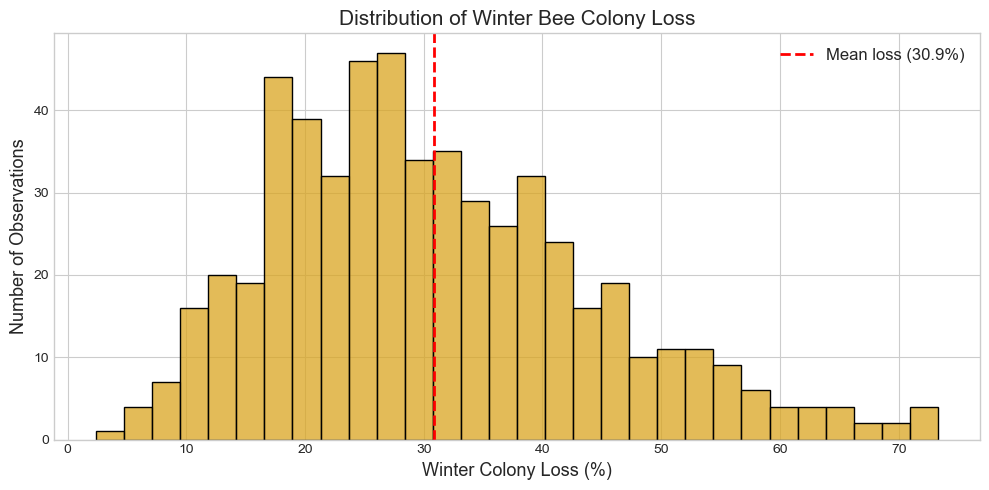

In [6]:
# Plot the distribution of our target variable
plt.figure(figsize=(10, 5))
sns.histplot(df['Loss'], bins=30, color='goldenrod', edgecolor='black')
plt.axvline(x=df['Loss'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean loss ({df["Loss"].mean():.1f}%)')
plt.xlabel('Winter Colony Loss (%)', fontsize=13)
plt.ylabel('Number of Observations', fontsize=13)
plt.title('Distribution of Winter Bee Colony Loss', fontsize=15)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Step 2 — Regression Tree vs. Linear Regression

In the Linear Regression notebook, we fit a single straight line through the data. A Regression Tree takes a different approach — it splits the data into rectangular regions and predicts the mean value within each region.

This means a Regression Tree can capture **non-linear patterns** that a straight line would miss. For example, if small and large operations both lose a lot of colonies but mid-size operations don't, a tree can detect that — a line cannot.

## Step 3 — Preprocessing

In [7]:
# Select features and target
X = df[['Colonies_Clean', 'Beekeepers_Clean']].to_numpy()
y = df['Loss'].to_numpy()

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Training set: {len(X_train)} samples')
print(f'Test set:     {len(X_test)} samples')

Training set: 445 samples
Test set:     112 samples


## Step 4 — Training and Evaluation

In [8]:
# Compare performance across different max_depth values
# This reveals the bias-variance tradeoff

depths = [1, 2, 3, 5, 7, 10]
train_mses = []
test_mses  = []

for depth in depths:
    tree = RegressionTreeRegressor(max_depth=depth)
    tree.fit(X_train, y_train)
    train_mses.append(tree.mean_squared_error(X_train, y_train))
    test_mses.append(tree.mean_squared_error(X_test, y_test))
    print(f'max_depth={depth:2d}  |  train MSE = {train_mses[-1]:.2f}  |  test MSE = {test_mses[-1]:.2f}')

max_depth= 1  |  train MSE = 170.73  |  test MSE = 144.06
max_depth= 2  |  train MSE = 165.84  |  test MSE = 148.09
max_depth= 3  |  train MSE = 156.27  |  test MSE = 139.21
max_depth= 5  |  train MSE = 135.05  |  test MSE = 176.27
max_depth= 7  |  train MSE = 107.08  |  test MSE = 227.92
max_depth=10  |  train MSE = 59.18  |  test MSE = 268.23


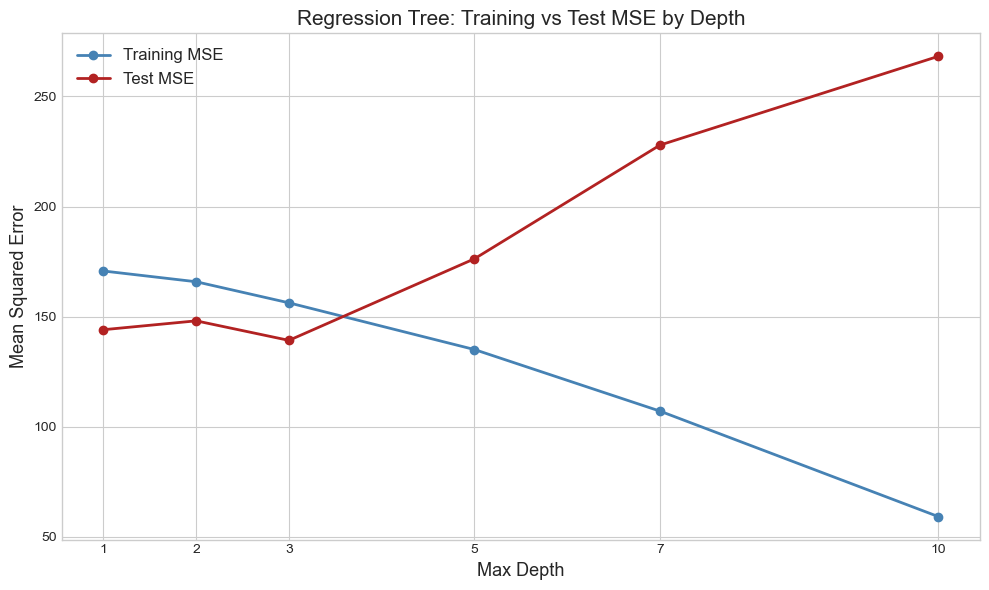

As depth increases, training MSE drops but test MSE eventually rises — that is overfitting!


In [9]:
# Plot train vs test MSE across depths
plt.figure(figsize=(10, 6))
plt.plot(depths, train_mses, marker='o', color='steelblue', linewidth=2, label='Training MSE')
plt.plot(depths, test_mses,  marker='o', color='firebrick', linewidth=2, label='Test MSE')
plt.xlabel('Max Depth', fontsize=13)
plt.ylabel('Mean Squared Error', fontsize=13)
plt.title('Regression Tree: Training vs Test MSE by Depth', fontsize=15)
plt.legend(fontsize=12)
plt.xticks(depths)
plt.tight_layout()
plt.show()

print('As depth increases, training MSE drops but test MSE eventually rises — that is overfitting!')

In [10]:
# Train the final model with the best depth
best_depth = depths[np.argmin(test_mses)]
print(f'Best max_depth = {best_depth}')

model = RegressionTreeRegressor(max_depth=best_depth)
model.fit(X_train, y_train)

print(f'Training MSE: {model.mean_squared_error(X_train, y_train):.4f}')
print(f'Test MSE:     {model.mean_squared_error(X_test, y_test):.4f}')
print(f'Test R²:      {model.r_squared(X_test, y_test):.4f}')

Best max_depth = 3
Training MSE: 156.2665
Test MSE:     139.2146
Test R²:      0.1237


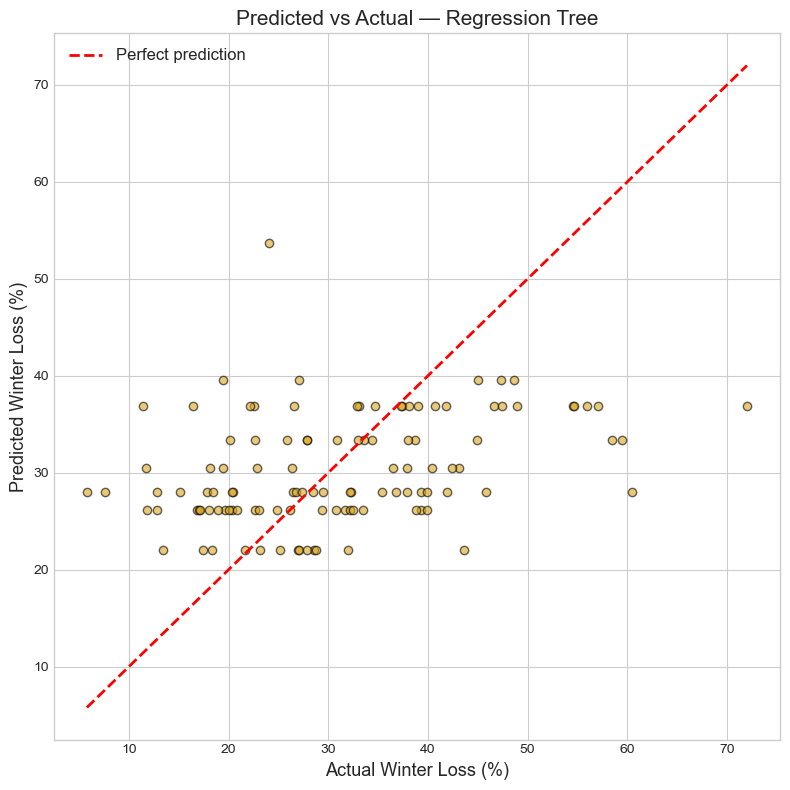

Points close to the red line = accurate predictions.
Points far from the red line = large errors.


In [11]:
# Plot predicted vs actual values
y_pred = model.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, color='goldenrod', edgecolors='black', alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Winter Loss (%)', fontsize=13)
plt.ylabel('Predicted Winter Loss (%)', fontsize=13)
plt.title('Predicted vs Actual — Regression Tree', fontsize=15)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print('Points close to the red line = accurate predictions.')
print('Points far from the red line = large errors.')

## Step 5 — Conclusion

### What did we find?

Our Regression Tree was trained to predict winter bee colony loss percentage from two features — colony count and number of beekeepers.

### Regression Tree vs. Linear Regression

| | Linear Regression | Regression Tree |
|---|---|---|
| **Output** | Predicts along a straight line | Predicts the mean within rectangular regions |
| **Non-linear patterns** | Cannot capture | Can capture |
| **Interpretability** | Very easy (slope + intercept) | Easy (follow the branches) |
| **Overfitting risk** | Low | High (deep trees) |

### Limitations

1. **Overfitting** — deep trees memorize the training data. Max depth must be tuned carefully.
2. **Step-function predictions** — the tree predicts piecewise constant values (flat lines within each region), not a smooth curve.
3. **Instability** — small changes in the data can produce a very different tree.

### What's next?

Next we move to **Decision Trees** for classification — predicting a category label instead of a number!